# Customer Churn Prediction --- Mini project 2

#### Problem Type --- Binary Classification
Target variable: Churn

Yes → Customer left

No → Customer stayed

#### Business Goal --- Predict whether a customer will churn or not

### Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


import warnings
warnings.filterwarnings("ignore")


### Load the Dataset

In [2]:
df = pd.read_csv("Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#Basic Dataset Check

df.shape
df.info()  #Understand dataset size, identifycal & categorical columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Target Variable Distribution

In [4]:
#Checking class imbalance (here it is imbalanced)
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [5]:
#Identify ID Columns

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
#removing customer id column, it is irrelavant

df.drop('customerID', axis=1, inplace=True)

### Data Cleaning

In [7]:
#Missing Values Check

df.isnull().sum()


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
#TotalCharges column appears numeric but is stored as object, so Fix TotalCharges

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.isnull().sum()       #now we can see missing values in total charges

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
#Handle Missing Values

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True) #Why median? it is robust to outliers

### Split X and y

In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']


## EDA

#### Churn vs Numerical Features

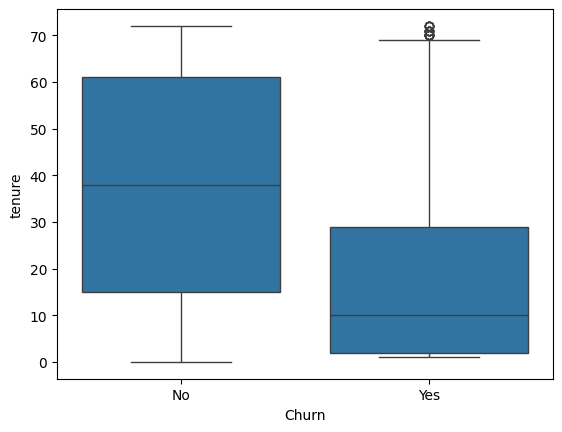

In [11]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

#### From above, churned customers → lower tenure

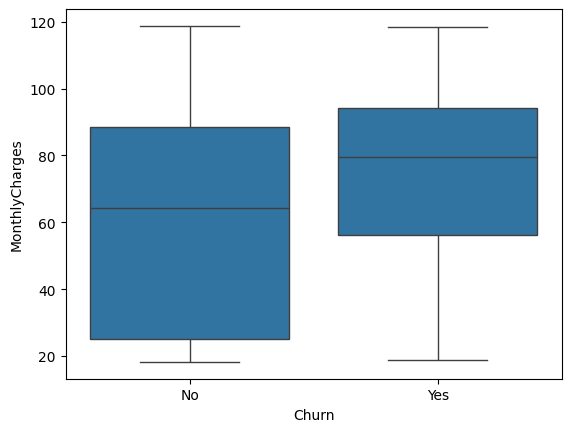

In [12]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

#### From above, monthly charges show visible churn differences

#### Churn vs Categorical Features

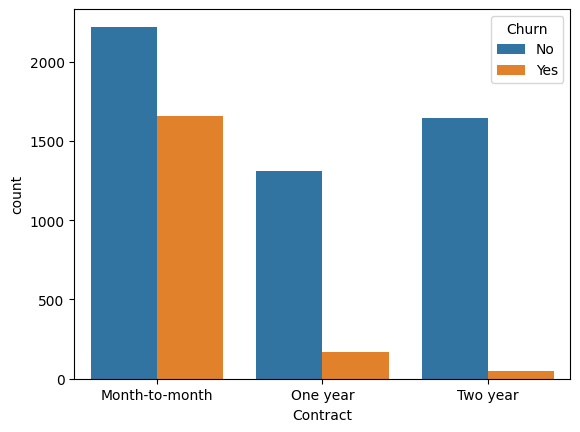

In [13]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

#### . From above, month-to-month customers churn more.
#### . long-term contracts reduce churn

## Statistical Hypothesis Testing

#### 1. t-test (MonthlyCharges vs Churn)

#### Since the p-value is far less than 0.05, MonthlyCharges is statistically significant and has a strong effect on customer churn.

##### The t-statistic (16.53) measures how far apart the two group means are.
|t| < 2 → weak difference

|t| > 2 → strong difference

|t| ≫ 10 → extremely strong difference

In [14]:
# if p-value < 0.05 → statistically significant

from scipy.stats import ttest_ind

churn_yes = df[df['Churn']=='Yes']['MonthlyCharges']
churn_no  = df[df['Churn']=='No']['MonthlyCharges']

ttest_ind(churn_yes, churn_no)


TtestResult(statistic=16.536738015936308, pvalue=2.7066456068884154e-60, df=7041.0)

#### 2. ANOVA Test (Tenure vs Churn)


#### Tenure statistically significant effect on churn.

##### The F-statistic (997.27) compares:

Variance between groups (churn vs non-churn)

In [15]:
from scipy.stats import f_oneway

f_oneway(df[df['Churn']=='Yes']['tenure'], df[df['Churn']=='No']['tenure'])


F_onewayResult(statistic=997.2680104991438, pvalue=7.999057960610892e-205)

## Feature Engineering


##### Derived Features----It improves model learning

In [16]:
df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)


In [17]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,60,72],
    labels=['0-1yr','1-2yr','2-4yr','4-5yr','5+yr']
)


## Encoding Categorical Variables

In [18]:
#Convert Target Variable

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})


In [19]:
#Encode Categorical Features --- One-Hot Encoding

df = pd.get_dummies(df, drop_first=True)  #Converts everything to numerical


## Correlation & Feature Selection

#### Correlation Heatmap

It identify multicollinearity, remove redundant features, choose optimal feature set

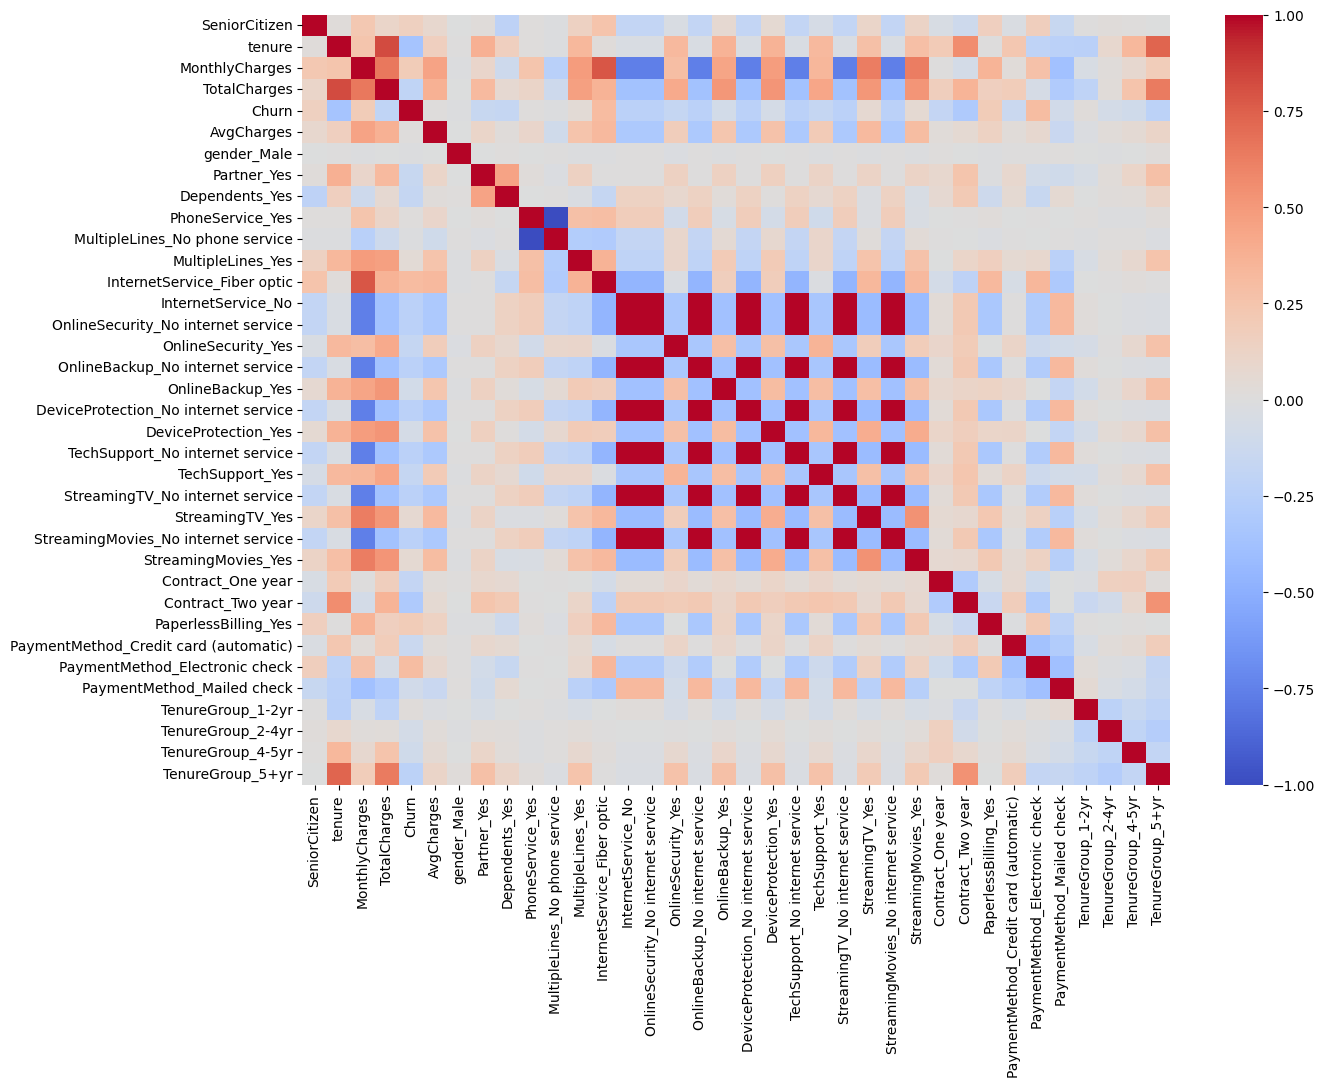

In [20]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()


### SelectKBest (ANOVA F-test)

#### Select the 10 features that are most statistically different between churned and non-churned customers

In [22]:
#SelectKBest selects the top K features that have the strongest statistical relationship with the target variable.

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier


X = df.drop('Churn', axis=1)
y = df['Churn']

# FS_1 → All features
FS_1 = X.columns.tolist()

# FS_2 → Correlation based
corr = df.corr()['Churn'].abs().sort_values(ascending=False)
FS_2 = corr[corr > 0.15].index.drop('Churn').tolist()

# FS_3 → Tree-based importance
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X, y)

importance = pd.Series(
    rf_temp.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

FS_3 = importance.head(10).index.tolist()

## Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Why stratify=y?----Maintains churn / non-churn ratio, Prevents biased evaluation

#From this point onwards → NEVER touch test data for learning

#### KEEP DATAFRAME COPIES

In [24]:
X_train_df = X_train.copy()
X_test_df  = X_test.copy()


### FEATURE IMPORTANCE (Tree-Based)

#### Feature importance was computed using the unscaled training data to preserve feature names, as Random Forest does not require feature scaling.

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_fs = RandomForestClassifier(random_state=42)
rf_fs.fit(X_train_df, y_train)

importance = pd.Series(
    rf_fs.feature_importances_,
    index=X_train_df.columns
).sort_values(ascending=False)

top_features = importance.head(10).index
top_features


Index(['TotalCharges', 'AvgCharges', 'tenure', 'MonthlyCharges',
       'PaymentMethod_Electronic check', 'InternetService_Fiber optic',
       'Contract_Two year', 'gender_Male', 'PaperlessBilling_Yes',
       'OnlineSecurity_Yes'],
      dtype='object')

### SELECT FEATURES

In [26]:
X_train_sel = X_train_df[top_features]
X_test_sel  = X_test_df[top_features]


## SCALING

In [27]:
#scaling (required for SVM & Logistic)

# Scaling for models that need it
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)


### Excel Auto-Appending Setup

In [28]:
excel_path = "ProjectRequirement_excel.xlsx"

def append_to_excel(row_dict):
    try:
        existing = pd.read_excel(excel_path)
        updated = pd.concat([existing, pd.DataFrame([row_dict])], ignore_index=True)
    except:
        updated = pd.DataFrame([row_dict])

    updated.to_excel(excel_path, index=False)


## MODEL BUILDING + HYPERPARAMETER TUNING (7 models)

#### Using GridSearchCV for each model.

## 1. Logistic Regression

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, solver='liblinear')

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(lr, lr_params, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_scaled,y_train)

y_pred = grid_lr.predict(X_test_scaled)

results.append([
    'Logistic Regression',
    grid_lr.best_params_,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
])


In [31]:
features = FS_1
Xtr = X_train[features]
Xte = X_test[features]

Xtr = scaler.fit_transform(Xtr)
Xte = scaler.transform(Xte)

lr = LogisticRegression(max_iter=1000)
lr.fit(Xtr, y_train)

y_pred = lr.predict(Xte)

row = {
    "Classifier ID": 1,
    "Churn Version": "1.0",
    "Classifier": "Logistic Regression",
    "Feature Set": "FS_1",
    "Hyperparameters": "default",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

append_to_excel(row)


PermissionError: [Errno 13] Permission denied: 'ProjectRequirement_excel.xlsx'

## 2. Support Vector Machine (SVM)

In [82]:
from sklearn.svm import SVC

svm = SVC()

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale']
}

grid_svm = GridSearchCV(svm, svm_params, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train_scaled,y_train)

y_pred = grid_svm.predict(X_test_scaled)

results.append([
    'SVM',
    grid_svm.best_params_,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
])


## 3. Decision Tree

In [98]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(dt, dt_params, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train_sel, y_train)

y_pred = grid_dt.predict(X_test_sel)

results.append([
    'Decision Tree',
    grid_dt.best_params_,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
])

best_dt = grid_dt.best_estimator_


## 4. Random Forest

In [84]:
rf = RandomForestClassifier(random_state=42)

rf_params = {'n_estimators': [100, 200]}

grid_rf = GridSearchCV(rf, rf_params, cv=5, scoring='f1')
grid_rf.fit(X_train_sel, y_train)

y_pred = grid_rf.predict(X_test_sel)

results.append([
    'Random Forest',
    grid_rf.best_params_,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
])



## 5. Gradient Boosting

In [85]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb_params = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]}

grid_gb = GridSearchCV(gb, gb_params, cv=5, scoring='f1')
grid_gb.fit(X_train_sel, y_train)

y_pred = grid_gb.predict(X_test_sel)

results.append([
    'Gradient Boosting',
    grid_gb.best_params_,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
])


## 6. AdaBoost

In [86]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)

ada_params = {'n_estimators': [50, 100]}

grid_ada = GridSearchCV(ada, ada_params, cv=5, scoring='f1')
grid_ada.fit(X_train_sel, y_train)

y_pred = grid_ada.predict(X_test_sel)

results.append([
    'AdaBoost',
    grid_ada.best_params_,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
])



## 7. SGBoost (Stochastic Gradient Boosting)


In [87]:
from sklearn.ensemble import GradientBoostingClassifier


sgb = GradientBoostingClassifier(random_state=42)

sgb_params ={
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample' : [0.8]           # <-- makes it STOCHASTIC
}

grid_sgb = GridSearchCV(
    sgb,
    sgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_sgb.fit(X_train_sel, y_train)

best_sgb = grid_sgb.best_estimator_

y_pred = best_sgb.predict(X_test_sel)


results.append([
    'Stochastic Gradient Boosting',
    grid_sgb.best_params_,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
])




## 8. XGBoost

In [89]:
!pip install xgboost

In [90]:
from xgboost import XGBClassifier

In [91]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb,
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train_sel, y_train)

#Predict using best estimator
best_xgb = grid_xgb.best_estimator_
y_pred = best_xgb.predict(X_test_sel)

#Store results
results.append([
    'XGBoost',
    grid_xgb.best_params_,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
])


## RESULTS TABLE

In [92]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Best Params', 'Accuracy', 'Precision', 'Recall', 'F1']
)

results_df


,Model,Best Params,Accuracy,Precision,Recall,F1
0,Logistic Regression,"{'C': 0.01, 'penalty': 'l2'}",0.784954,0.617162,0.500000,0.552437
1,SVM,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.797019,0.643791,0.526738,0.579412
2,Decision Tree,"{'max_depth': 5, 'min_samples_split': 2}",0.794180,0.622807,0.569519,0.594972
3,Random Forest,{'n_estimators': 200},0.775727,0.592357,0.497326,0.540698
4,Gradient Boosting,"{'learning_rate': 0.05, 'n_estimators': 100}",0.794890,0.654545,0.481283,0.554700
5,AdaBoost,{'n_estimators': 100},0.789922,0.638298,0.481283,0.548780
6,Stochastic Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.797019,0.651724,0.505348,0.569277
7,XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.796309,0.650519,0.502674,0.567119


In [93]:
results_df.to_csv("model_results_summary.csv", index=False)


#### Although the Decision Tree achieved the highest F1-score, it is prone to overfitting. Stochastic Gradient Boosting provided a comparable F1-score with better generalization and stability, making it more suitable for churn prediction. Final model selection was based not only on F1-score but also on robustness, generalisation ability, and business applicability.

## Cross-Validation Mean F1

##### This proves stability

### 1. SGBoost

In [94]:
from sklearn.model_selection import cross_val_score

cv_f1_sgb = cross_val_score(
    best_sgb,
    X_train_sel,
    y_train,
    cv=5,
    scoring='f1'
)

print("SGBoost CV F1 scores:", cv_f1_sgb)
print("Mean CV F1:", cv_f1_sgb.mean())


SGBoost CV F1 scores: [0.59622642 0.56746032 0.58666667 0.54814815 0.53007519]
Mean CV F1: 0.5657153470678793


### 2. XGBoost

In [95]:
cv_f1_xgb = cross_val_score(
    best_xgb,
    X_train_sel,
    y_train,
    cv=5,
    scoring='f1'
)

print("XGBoost Mean CV F1:", cv_f1_xgb.mean())


XGBoost Mean CV F1: 0.5658536498810269


### 3. Decision Tree

In [99]:
cv_f1_dt = cross_val_score(
    best_dt,
    X_train_sel,
    y_train,
    cv=5,
    scoring='f1'
)

print("Decision Tree Mean CV F1:", cv_f1_dt.mean())


Decision Tree Mean CV F1: 0.5082239121082519


### Conslusion --- SGBoost generalizes better, high mean CV F1
### When two models (sgb and xgb) perform equally well, the simpler and more interpretable model is preferred. xgb is a complex one so sgb is choosed here as the best.

## Confusion Matrix

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


### SGBoost Confusion Matrix

#### A good churn model minimizes False Negatives.

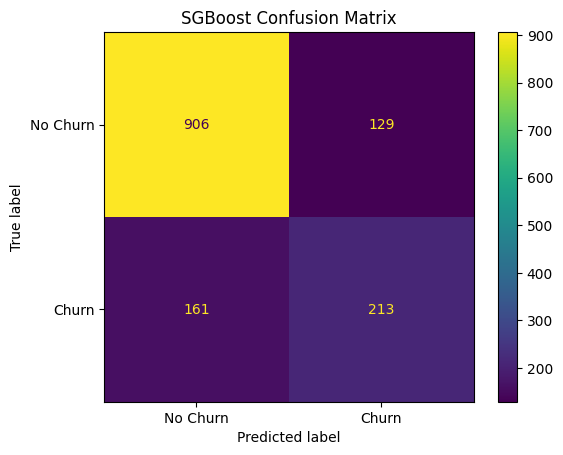

In [101]:
cm_sgb = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sgb,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title("SGBoost Confusion Matrix")
plt.show()


### ROC–AUC Curve (Classifier Quality)

In [102]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay


In [104]:
#Predict probabilities
y_prob_sgb = best_sgb.predict_proba(X_test_sel)[:, 1]


In [106]:
#ROC-AUC Score

auc_sgb = roc_auc_score(y_test, y_prob_sgb)
print("SGBoost ROC-AUC:", auc_sgb)



SGBoost ROC-AUC: 0.8356945413211398


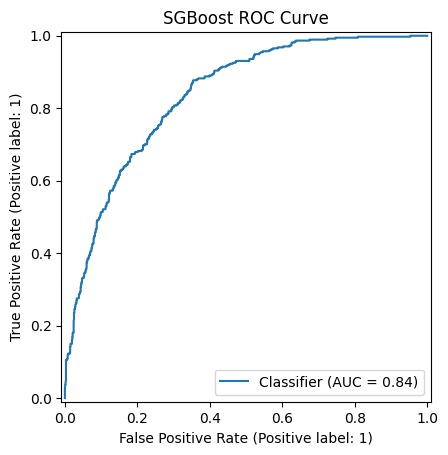

In [107]:
#Plot ROC Curve

RocCurveDisplay.from_predictions(y_test, y_prob_sgb)
plt.title("SGBoost ROC Curve")
plt.show()


### SGB ROC–AUC ≈ 0.836, Among all trained models, Stochastic Gradient Boosting (SGB) was selected as the final model due to its strong ROC–AUC performance, balanced precision–recall tradeoff, and stable generalization behavior.